# MaternalCare AI — EDA & Model Training
**Dataset:** Maternal Health Risk Dataset (Kaggle)  
**Goal:** Predict maternal health risk level (Low / Mid / High) using vital signs.

In [23]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Model persistence
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load the Dataset

In [24]:
import pandas as pd

df = pd.read_csv(r"/content/Maternal Health Risk Data Set.csv")

print("Shape:", df.shape)

df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 2. Dataset Overview

In [25]:
print("Dataset Info:")
print("-" * 40)
df.info()
print()
print("Statistical Summary:")
df.describe()

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB

Statistical Summary:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [26]:
print("Missing Values per Column:")
print(df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())

Missing Values per Column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate Rows: 562


## 3. Exploratory Data Analysis (EDA)

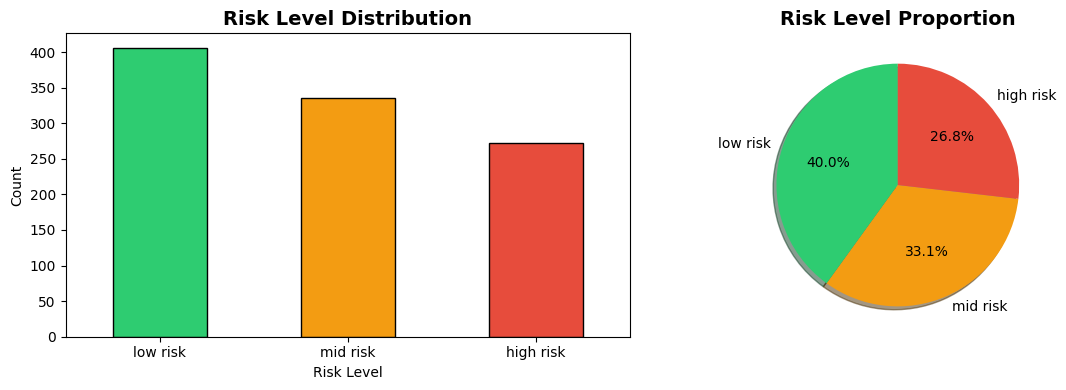

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [27]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
order = ['low risk', 'mid risk', 'high risk']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['RiskLevel'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black'
)
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['RiskLevel'].value_counts().reindex(order).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=colors, startangle=90, shadow=True
)
axes[1].set_title('Risk Level Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print(df['RiskLevel'].value_counts())

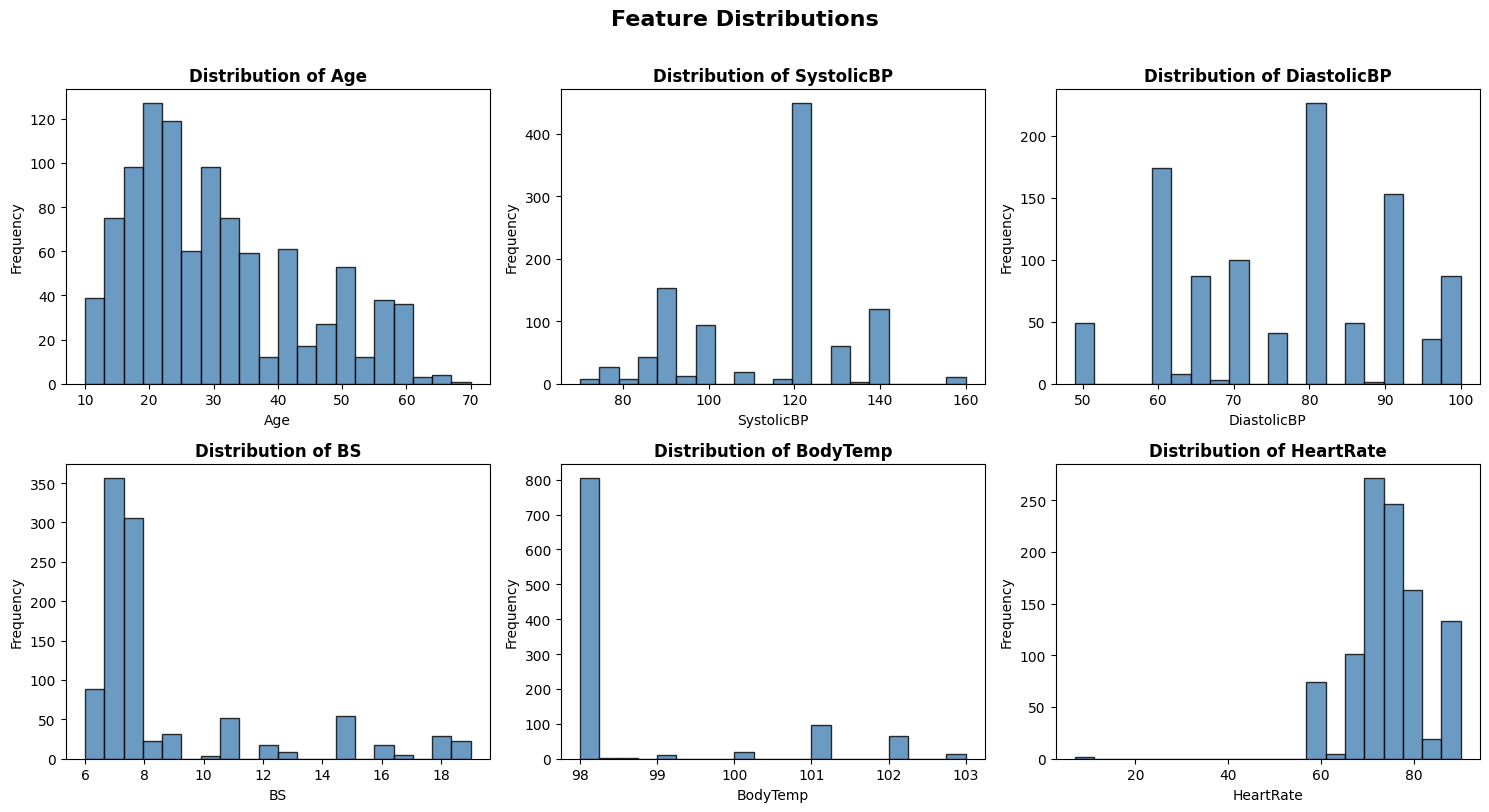

In [28]:
# Distribution of each feature
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

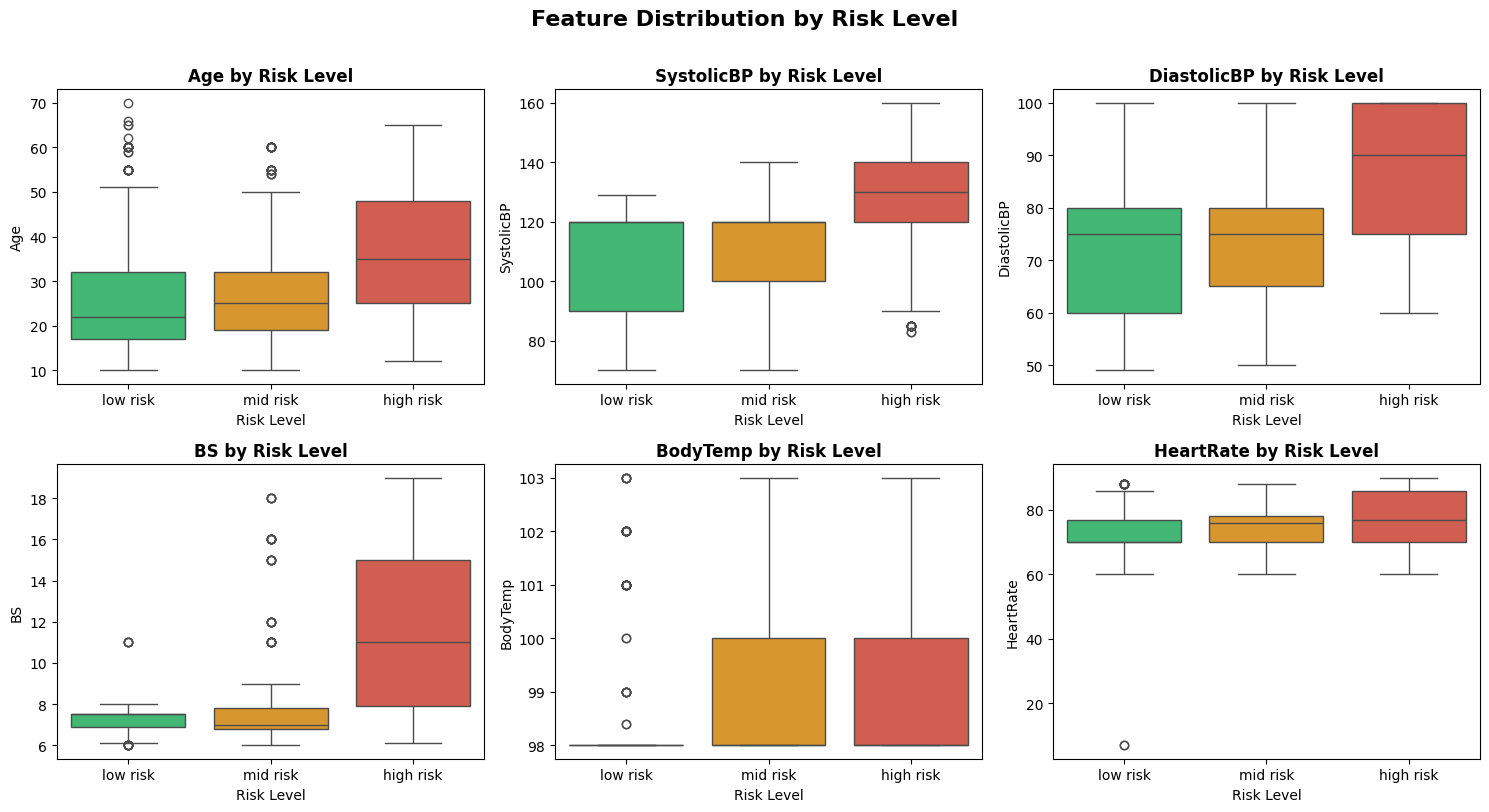

In [29]:
# Boxplots: feature vs risk level
import seaborn as sns  # ← add this line

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

for i, col in enumerate(features):
    sns.boxplot(data=df, x='RiskLevel', y=col, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} by Risk Level', fontweight='bold')
    axes[i].set_xlabel('Risk Level')

plt.suptitle('Feature Distribution by Risk Level', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

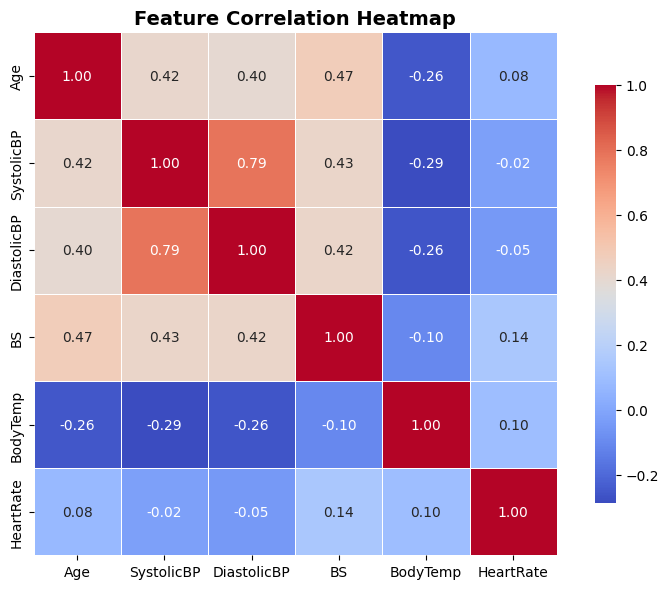

In [30]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [31]:
# Encode target label
from sklearn.preprocessing import LabelEncoder  # ← add this line

le = LabelEncoder()
df['RiskLevel_encoded'] = le.fit_transform(df['RiskLevel'])

print("Label Encoding Mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {cls}  →  {idx}")

X = df[['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']]
y = df['RiskLevel_encoded']

from sklearn.model_selection import train_test_split  # ← add this too

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Label Encoding Mapping:
  high risk  →  0
  low risk  →  1
  mid risk  →  2

Training samples : 811
Testing  samples : 203


## 5. Model Training & Comparison

In [32]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(probability=True, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:<25} Accuracy: {acc:.4f} ({acc*100:.2f}%)")

best_model_name = max(results, key=results.get)
print(f"\n✅ Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")

Logistic Regression       Accuracy: 0.6207 (62.07%)
Decision Tree             Accuracy: 0.8374 (83.74%)
Random Forest             Accuracy: 0.8621 (86.21%)
K-Nearest Neighbors       Accuracy: 0.6995 (69.95%)
SVM                       Accuracy: 0.5862 (58.62%)
Naive Bayes               Accuracy: 0.6158 (61.58%)

✅ Best Model: Random Forest (86.21%)


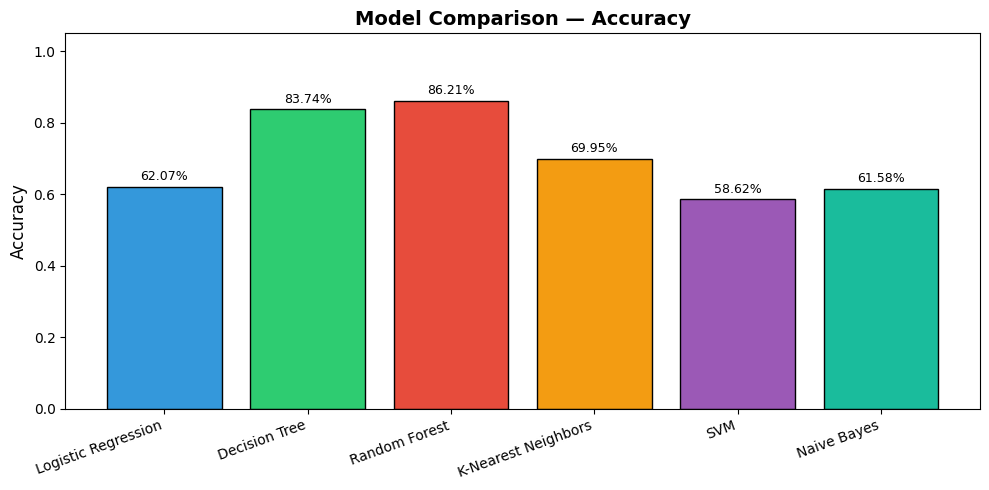

In [33]:
# Compare model accuracies
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c'],
               edgecolor='black')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison — Accuracy', fontsize=14, fontweight='bold')
plt.xticks(rotation=20, ha='right')

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Random Forest — Detailed Evaluation

In [34]:
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

print("Classification Report — Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Classification Report — Random Forest
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.89      0.80      0.84        81
    mid risk       0.76      0.87      0.81        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.86      0.86       203



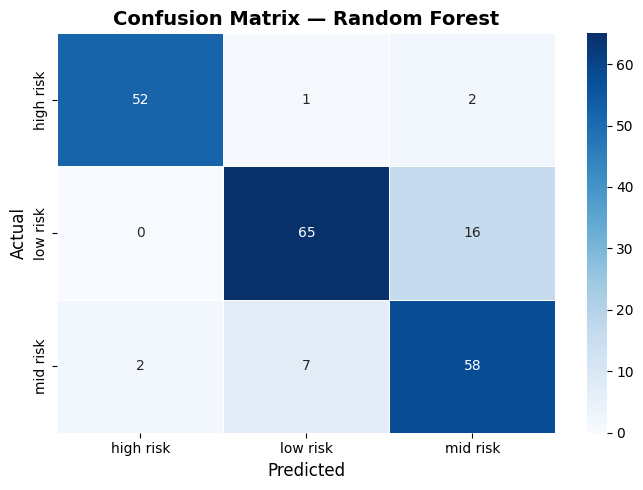

In [35]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

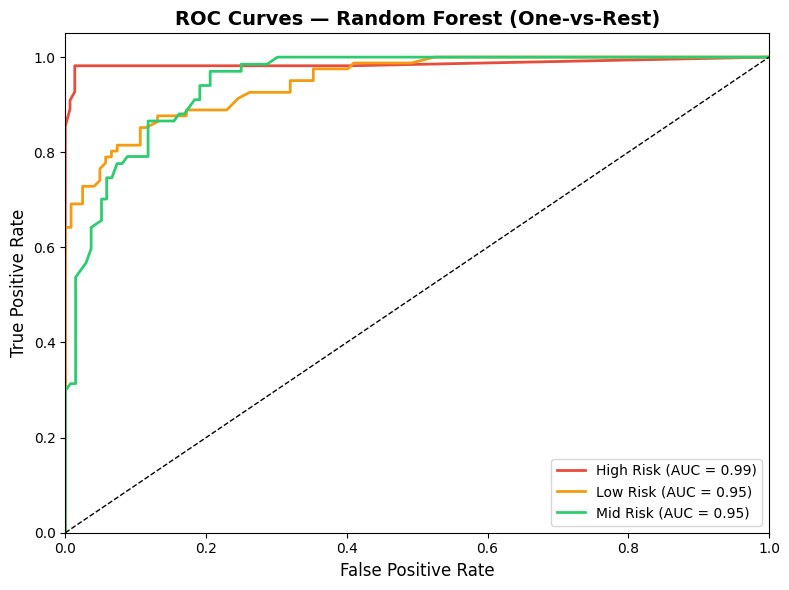

In [36]:
# Multi-class ROC curves (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score    = rf_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors_roc = ['#e74c3c', '#f39c12', '#2ecc71']

for i, (cls, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls.title()} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Random Forest (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

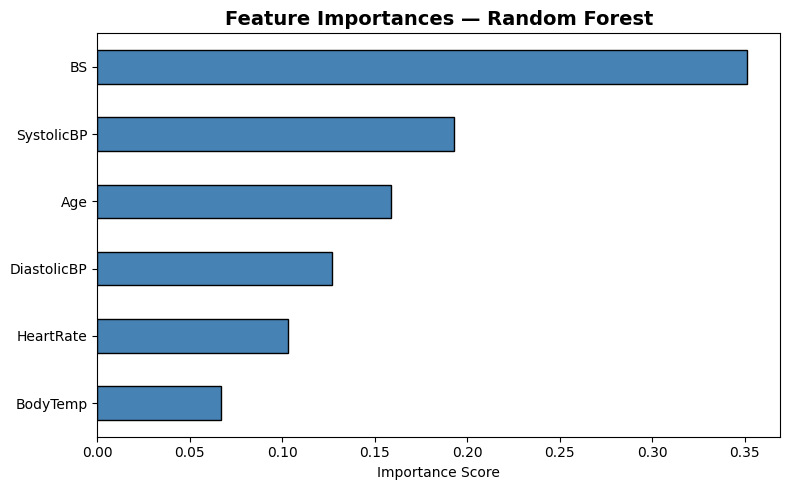

Feature Importances:
  BS              0.3516
  SystolicBP      0.1926
  Age             0.1589
  DiastolicBP     0.1270
  HeartRate       0.1030
  BodyTemp        0.0669


In [37]:
# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importances:")
for feat, score in importances.sort_values(ascending=False).items():
    print(f"  {feat:<15} {score:.4f}")

## 7. Save the Trained Model

In [38]:
# Save Random Forest model and label encoder for use in Streamlit app
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Model saved as  : rf_model.pkl")
print("✅ Encoder saved as: label_encoder.pkl")

✅ Model saved as  : rf_model.pkl
✅ Encoder saved as: label_encoder.pkl


## 8. Summary

| Model | Accuracy |
|---|---|
| Logistic Regression | see output above |
| Decision Tree | see output above |
| **Random Forest** | **best performer** |
| K-Nearest Neighbors | see output above |
| SVM | see output above |
| Naive Bayes | see output above |

**Random Forest** was selected as the final model for the MaternalCare AI Streamlit app because it achieved the highest accuracy, handles multi-class classification well, and provides feature importances for interpretability.

The trained model (`rf_model.pkl`) and label encoder (`label_encoder.pkl`) are saved and ready to be loaded in `app.py`.

## 9. Write app.py to Colab

In [39]:
app_code = '''import streamlit as st
import pickle
import numpy as np
from datetime import date, timedelta

st.set_page_config(page_title="MaternalCare AI", page_icon="🤰", layout="centered", initial_sidebar_state="expanded")

st.markdown("""
<style>
.stApp { background-color: #fdf6ff; }
.main-header { background: linear-gradient(135deg, #6C3483, #A569BD); padding: 28px 24px 20px 24px; border-radius: 14px; text-align: center; margin-bottom: 28px; color: white; }
.main-header h1 { margin: 0; font-size: 2.2rem; }
.main-header p { margin: 6px 0 0; font-size: 1rem; opacity: 0.88; }
.result-high { background: #fdecea; border-left: 6px solid #e74c3c; padding: 18px 20px; border-radius: 10px; margin-top: 14px; }
.result-mid { background: #fef9ec; border-left: 6px solid #f39c12; padding: 18px 20px; border-radius: 10px; margin-top: 14px; }
.result-low { background: #eafaf1; border-left: 6px solid #2ecc71; padding: 18px 20px; border-radius: 10px; margin-top: 14px; }
.result-title { font-size: 1.3rem; font-weight: 700; margin-bottom: 6px; }
section[data-testid="stSidebar"] { background-color: #f3e8ff; }
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    with open("rf_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("label_encoder.pkl", "rb") as f:
        le = pickle.load(f)
    return model, le

try:
    model, le = load_model()
    model_loaded = True
except FileNotFoundError:
    model_loaded = False

st.markdown("""
<div class="main-header">
    <h1>🤰 MaternalCare AI</h1>
    <p>Maternal Health Risk Prediction · BMI Calculator · Expected Delivery Date</p>
</div>
""", unsafe_allow_html=True)

st.sidebar.markdown("## Navigation")
page = st.sidebar.radio("Choose a module:", ["🔬 Risk Prediction", "⚖️ BMI Calculator", "📅 Delivery Date"], label_visibility="collapsed")
st.sidebar.markdown("---")
st.sidebar.markdown("**About MaternalCare AI**\n\nRandom Forest ML · BMI · EDD\n\n*MSE Project · Ramya · Yada · Celestine*")

if page == "🔬 Risk Prediction":
    st.markdown("### 🔬 Maternal Health Risk Prediction")
    st.caption("Enter your health measurements below. The AI model will predict your risk level.")
    if not model_loaded:
        st.error("⚠️ Model files not found. Run the Save Model cell in your notebook first.")
        st.stop()
    with st.form("risk_form"):
        st.markdown("#### Patient Health Inputs")
        col1, col2 = st.columns(2)
        with col1:
            age = st.number_input("Age (years)", min_value=10, max_value=70, value=25)
            systolic_bp = st.number_input("Systolic BP (mmHg)", min_value=70, max_value=180, value=120)
            diastolic_bp = st.number_input("Diastolic BP (mmHg)", min_value=40, max_value=120, value=80)
        with col2:
            bs = st.number_input("Blood Sugar (mmol/L)", min_value=3.0, max_value=20.0, value=7.0, step=0.1)
            body_temp = st.number_input("Body Temperature (°F)", min_value=97.0, max_value=104.0, value=98.0, step=0.1)
            heart_rate = st.number_input("Heart Rate (bpm)", min_value=40, max_value=100, value=76)
        submitted = st.form_submit_button("🔍 Predict Risk Level", use_container_width=True)
    if submitted:
        input_data = np.array([[age, systolic_bp, diastolic_bp, bs, body_temp, heart_rate]])
        prediction_encoded = model.predict(input_data)[0]
        prediction_label = le.inverse_transform([prediction_encoded])[0]
        probabilities = model.predict_proba(input_data)[0]
        if prediction_label == "high risk":
            css, emoji, advice = "result-high", "🔴", "High Risk detected. Please consult a doctor immediately."
        elif prediction_label == "mid risk":
            css, emoji, advice = "result-mid", "🟡", "Mid Risk detected. Schedule a check-up with your healthcare provider."
        else:
            css, emoji, advice = "result-low", "🟢", "Low Risk. Keep maintaining healthy habits and regular prenatal check-ups."
        st.markdown(f\'\'\'<div class="{css}"><div class="result-title">{emoji} Predicted Risk Level: {prediction_label.title()}</div><p style="margin:0">{advice}</p></div>\'\'\', unsafe_allow_html=True)
        st.markdown("#### Model Confidence")
        for cls, prob in zip(le.classes_, probabilities):
            st.markdown(f"**{cls.title()}**")
            st.progress(float(prob), text=f"{prob*100:.1f}%")
        with st.expander("📋 View Input Summary"):
            st.markdown(f"| Parameter | Value |\\n|---|---|\\n| Age | {age} yrs |\\n| Systolic BP | {systolic_bp} mmHg |\\n| Diastolic BP | {diastolic_bp} mmHg |\\n| Blood Sugar | {bs} mmol/L |\\n| Body Temp | {body_temp} °F |\\n| Heart Rate | {heart_rate} bpm |")
        st.info("⚠️ This tool is for informational purposes only.")

elif page == "⚖️ BMI Calculator":
    st.markdown("### ⚖️ BMI Calculator")
    st.caption("Calculate your Body Mass Index using the standard WHO formula.")
    with st.form("bmi_form"):
        col1, col2 = st.columns(2)
        with col1:
            weight = st.number_input("Weight (kg)", min_value=30.0, max_value=200.0, value=60.0, step=0.5)
        with col2:
            height_cm = st.number_input("Height (cm)", min_value=100.0, max_value=220.0, value=160.0, step=0.5)
        submitted_bmi = st.form_submit_button("⚖️ Calculate BMI", use_container_width=True)
    if submitted_bmi:
        height_m = height_cm / 100
        bmi = weight / (height_m ** 2)
        if bmi < 18.5:
            category, css, emoji = "Underweight", "result-mid", "🟡"
        elif bmi < 25.0:
            category, css, emoji = "Normal Weight", "result-low", "🟢"
        elif bmi < 30.0:
            category, css, emoji = "Overweight", "result-mid", "🟡"
        else:
            category, css, emoji = "Obese", "result-high", "🔴"
        st.markdown(f\'\'\'<div class="{css}"><div class="result-title">{emoji} BMI: {bmi:.2f} — {category}</div></div>\'\'\', unsafe_allow_html=True)
        st.markdown("#### BMI Categories")
        for label, colour, cat in [("Underweight (< 18.5)","#3498db","Underweight"),("Normal (18.5–24.9)","#2ecc71","Normal Weight"),("Overweight (25.0–29.9)","#f39c12","Overweight"),("Obese (≥ 30.0)","#e74c3c","Obese")]:
            marker = " ◀ Your BMI" if cat == category else ""
            st.markdown(f\'\'\'<div style="background:{colour};color:white;padding:7px 14px;border-radius:6px;margin:3px 0;font-weight:600">{label}{marker}</div>\'\'\', unsafe_allow_html=True)
        with st.expander("📐 Show Calculation"):
            st.markdown(f"BMI = {weight} ÷ {height_m**2:.4f} = **{bmi:.2f}**")
        st.info("⚠️ BMI is a general indicator only.")

elif page == "📅 Delivery Date":
    st.markdown("### 📅 Expected Delivery Date Calculator")
    st.caption("Calculate your EDD using Naegele\'s Rule.")
    with st.form("edd_form"):
        lmp = st.date_input("Last Menstrual Period (LMP)", value=date.today() - timedelta(weeks=8), max_value=date.today())
        submitted_edd = st.form_submit_button("📅 Calculate Due Date", use_container_width=True)
    if submitted_edd:
        edd = lmp + timedelta(days=280)
        today = date.today()
        days_elapsed = (today - lmp).days
        weeks_preg = days_elapsed // 7
        days_rem = days_elapsed % 7
        days_to_edd = (edd - today).days
        trimester = "First Trimester (Weeks 1–12)" if weeks_preg <= 12 else "Second Trimester (Weeks 13–26)" if weeks_preg <= 26 else "Third Trimester (Weeks 27–40)"
        css = "result-low" if days_to_edd > 0 else "result-high"
        st.markdown(f\'\'\'<div class="{css}"><div class="result-title">🍼 Expected Delivery Date: {edd.strftime("%d %B %Y")}</div><p style="margin:0">{days_to_edd} day(s) remaining.</p></div>\'\'\', unsafe_allow_html=True)
        c1, c2, c3 = st.columns(3)
        c1.metric("Weeks Pregnant", f"{weeks_preg}w {days_rem}d")
        c2.metric("Due Date", edd.strftime("%d %b %Y"))
        c3.metric("Days Remaining", max(0, days_to_edd))
        st.markdown(f"**Current Stage:** {trimester}")
        for title, weeks, bg, desc in [("🌱 First Trimester","Weeks 1–12","#d6eaf8","Baby\\'s organs begin forming."),("🌸 Second Trimester","Weeks 13–26","#d5f5e3","Baby starts moving."),("🌟 Third Trimester","Weeks 27–40","#fef9e7","Baby grows rapidly.")]:
            st.markdown(f\'\'\'<div style="background:{bg};padding:12px 16px;border-radius:8px;margin:4px 0"><b>{title}</b> ({weeks})<br><small>{desc}</small></div>\'\'\', unsafe_allow_html=True)
        with st.expander("📐 Naegele\'s Rule"):
            st.markdown(f"EDD = {lmp.strftime(\'%d %B %Y\')} + 280 days = **{edd.strftime(\'%d %B %Y\')}**")
        st.info("⚠️ EDD is an estimate. Always consult your doctor.")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

import os
print("✅ app.py written, size:", os.path.getsize('/content/app.py'), "bytes")

✅ app.py written, size: 8749 bytes


## 10. Launch MaternalCare AI

In [40]:
!pip install streamlit -q

import subprocess, threading, time, re, urllib.request, os

for fname in ['rf_model.pkl', 'label_encoder.pkl']:
    path = f'/content/{fname}'
    print(('✅ Found: ' if os.path.exists(path) else '❌ MISSING: ') + path)

def run_streamlit():
    subprocess.run(['streamlit', 'run', '/content/app.py',
                    '--server.port', '8501', '--server.headless', 'true'])

threading.Thread(target=run_streamlit, daemon=True).start()
time.sleep(6)

if not os.path.exists('/content/cloudflared'):
    urllib.request.urlretrieve(
        'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64',
        '/content/cloudflared')
    subprocess.run(['chmod', '+x', '/content/cloudflared'])

tunnel = subprocess.Popen(
    ['/content/cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, universal_newlines=True)

print("⏳ Getting tunnel URL...")
for _ in range(40):
    line = tunnel.stdout.readline()
    if line.strip(): print(line.strip())
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
    if match:
        print("\n" + "="*55)
        print("🚀 MaternalCare AI is LIVE:")
        print(match.group())
        print("="*55)
        break
    time.sleep(1)

✅ Found: /content/rf_model.pkl
✅ Found: /content/label_encoder.pkl
⏳ Getting tunnel URL...
2026-05-27T11:45:52Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-27T11:45:52Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-27T11:45:55Z INF +--------------------------------------------------------------------------------------------+
2026-05-27T11:45:55Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reach